In [1]:
# Importar librerías
%pip install -q pandas numpy matplotlib openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

Note: you may need to restart the kernel to use updated packages.


In [2]:
# %% Importar datos y limpiar encabezados
DataSet = pd.read_excel("MatLabVer-AVEVA_2026AcademicCompetition_AllData.xlsx")
 
def clean_header(h: str) -> str:
    h = re.sub(r'Value.*$', '', h)      # quita todo después de 'Value'
    h = re.sub(r'[^a-zA-Z0-9]', '', h)  # deja solo letras y números
    return h
 
DataSet.columns = [clean_header(c) for c in DataSet.columns]

In [3]:
# %% Convertir el timestamp string a datetime (equivalente a table2timetable)
DataSet['Timestamp'] = pd.to_datetime(
    DataSet['Timestamp'],
    format='%Y-%m-%dT%H:%M:%S.%f%z'   # equivale a yyyy-MM-dd'T'HH:mm:ss.SSSSSSS'Z'
)

In [4]:
if DataSet['Timestamp'].dt.tz is None:
    DataSet['Timestamp'] = DataSet['Timestamp'].dt.tz_localize('UTC')
else:
    DataSet['Timestamp'] = DataSet['Timestamp'].dt.tz_convert('UTC')
 
TimedDataSet = DataSet.set_index('Timestamp')
TimedDataSet

,AT1100PV,AT1104PV,AT1201PV,FC1002PV,FC1002SP,FRC1004PV,FRC1004SP,FT1001PV,FT1002PV,FT1003PV,...,TC1215PV,TC1215SP,TT1001PV,TT1004PV,TT1005PV,TT1006PV,TT1100PV,TT1102PV,TT1103PV,TT1211PV
Timestamp,,,,,,,,,,,,,,,,,,,,,
2025-10-12 15:00:00+00:00,37.378,797.951,730.840,15000.000,15000.0,5.0,5.0,5328.461,15000.000,15000.000,...,104.581,104.581,30.314,207.462,350.000,341.570,440.571,40.012,90.000,40.000
2025-10-12 15:01:00+00:00,37.378,797.951,730.840,15000.000,15000.0,5.0,5.0,5328.461,15000.000,15000.000,...,104.581,104.581,30.314,207.462,350.000,341.570,440.571,40.012,90.000,40.000
2025-10-12 15:02:00+00:00,37.378,797.951,730.840,15000.000,15000.0,5.0,5.0,5328.461,15000.000,15000.000,...,104.581,104.581,30.314,207.462,350.000,341.570,440.571,40.012,90.000,40.000
2025-10-12 15:03:00+00:00,37.378,797.951,730.840,15000.000,15000.0,5.0,5.0,5328.461,15000.000,15000.000,...,104.581,104.581,30.314,207.462,350.000,341.570,440.571,40.012,90.000,40.000
2025-10-12 15:04:00+00:00,37.378,797.951,730.840,15000.000,15000.0,5.0,5.0,5328.461,15000.000,15000.000,...,104.581,104.581,30.314,207.462,350.000,341.570,440.571,40.012,90.000,40.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-18 01:56:00+00:00,33.408,799.545,770.886,13500.049,13500.0,5.0,5.0,4530.430,13500.049,13500.049,...,104.319,104.581,30.314,206.281,323.030,350.011,470.817,51.767,85.863,39.918
2025-10-18 01:57:00+00:00,33.409,799.560,770.740,13500.048,13500.0,5.0,5.0,4531.854,13500.048,13500.048,...,104.367,104.581,30.314,206.280,323.023,350.009,470.814,51.886,85.880,39.898
2025-10-18 01:58:00+00:00,33.411,799.574,770.599,13500.047,13500.0,5.0,5.0,4533.346,13500.047,13500.047,...,104.411,104.581,30.314,206.280,323.016,350.007,470.808,52.007,85.898,39.880


In [5]:
# %% Selección de grupos de variables por posición de columna
# Densidad: B-D (1-3) kg/m3
Densidad = TimedDataSet.iloc[:, 0:3]
 
# Flujo: E-S (4-18) kg/h
Flujo = TimedDataSet.iloc[:, 3:18]
 
# Nivel: T-AA (19-26) %
Nivel = TimedDataSet.iloc[:, 18:26]
 
# Presión: AB-AG (27-32) kPa
Presion = TimedDataSet.iloc[:, 26:32]
 
# Temperatura: AH-AY (33-50) °C
Temperatura = TimedDataSet.iloc[:, 32:50]

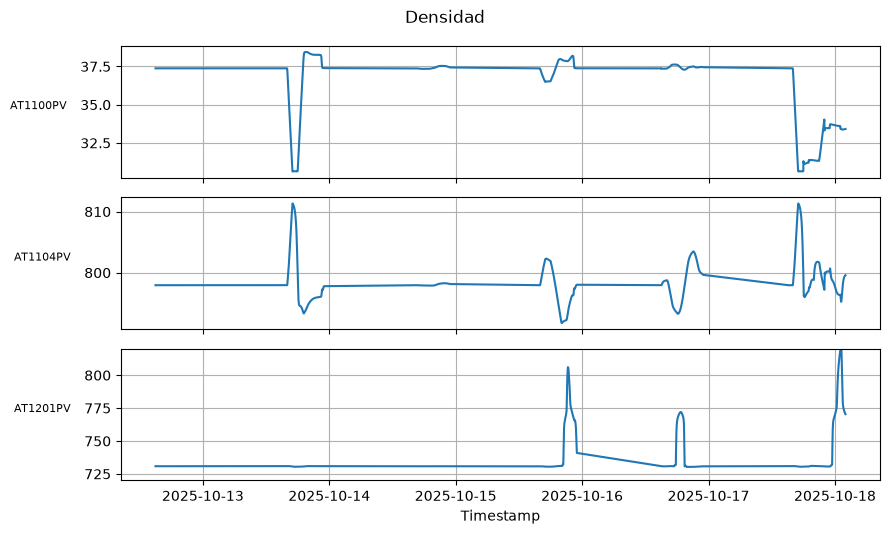

In [6]:
# %% Función auxiliar para simular stackedplot de MATLAB
def stacked_plot(df: pd.DataFrame, title: str = ""):
    cols = df.columns
    fig, axes = plt.subplots(len(cols), 1, sharex=True, figsize=(9, 1.8 * len(cols)))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        ax.plot(df.index, df[col])
        ax.set_ylabel(col, rotation=0, labelpad=30, fontsize=8)
        ax.grid(True)
    axes[-1].set_xlabel("Timestamp")
    fig.suptitle(title)
    fig.tight_layout()
    return fig, axes

# %% Gráfico de Densidad (con límite Y en el 3er eje, como en MATLAB)
fig, axes = stacked_plot(Densidad, "Densidad")
axes[2].set_ylim(720, 820)
plt.show()

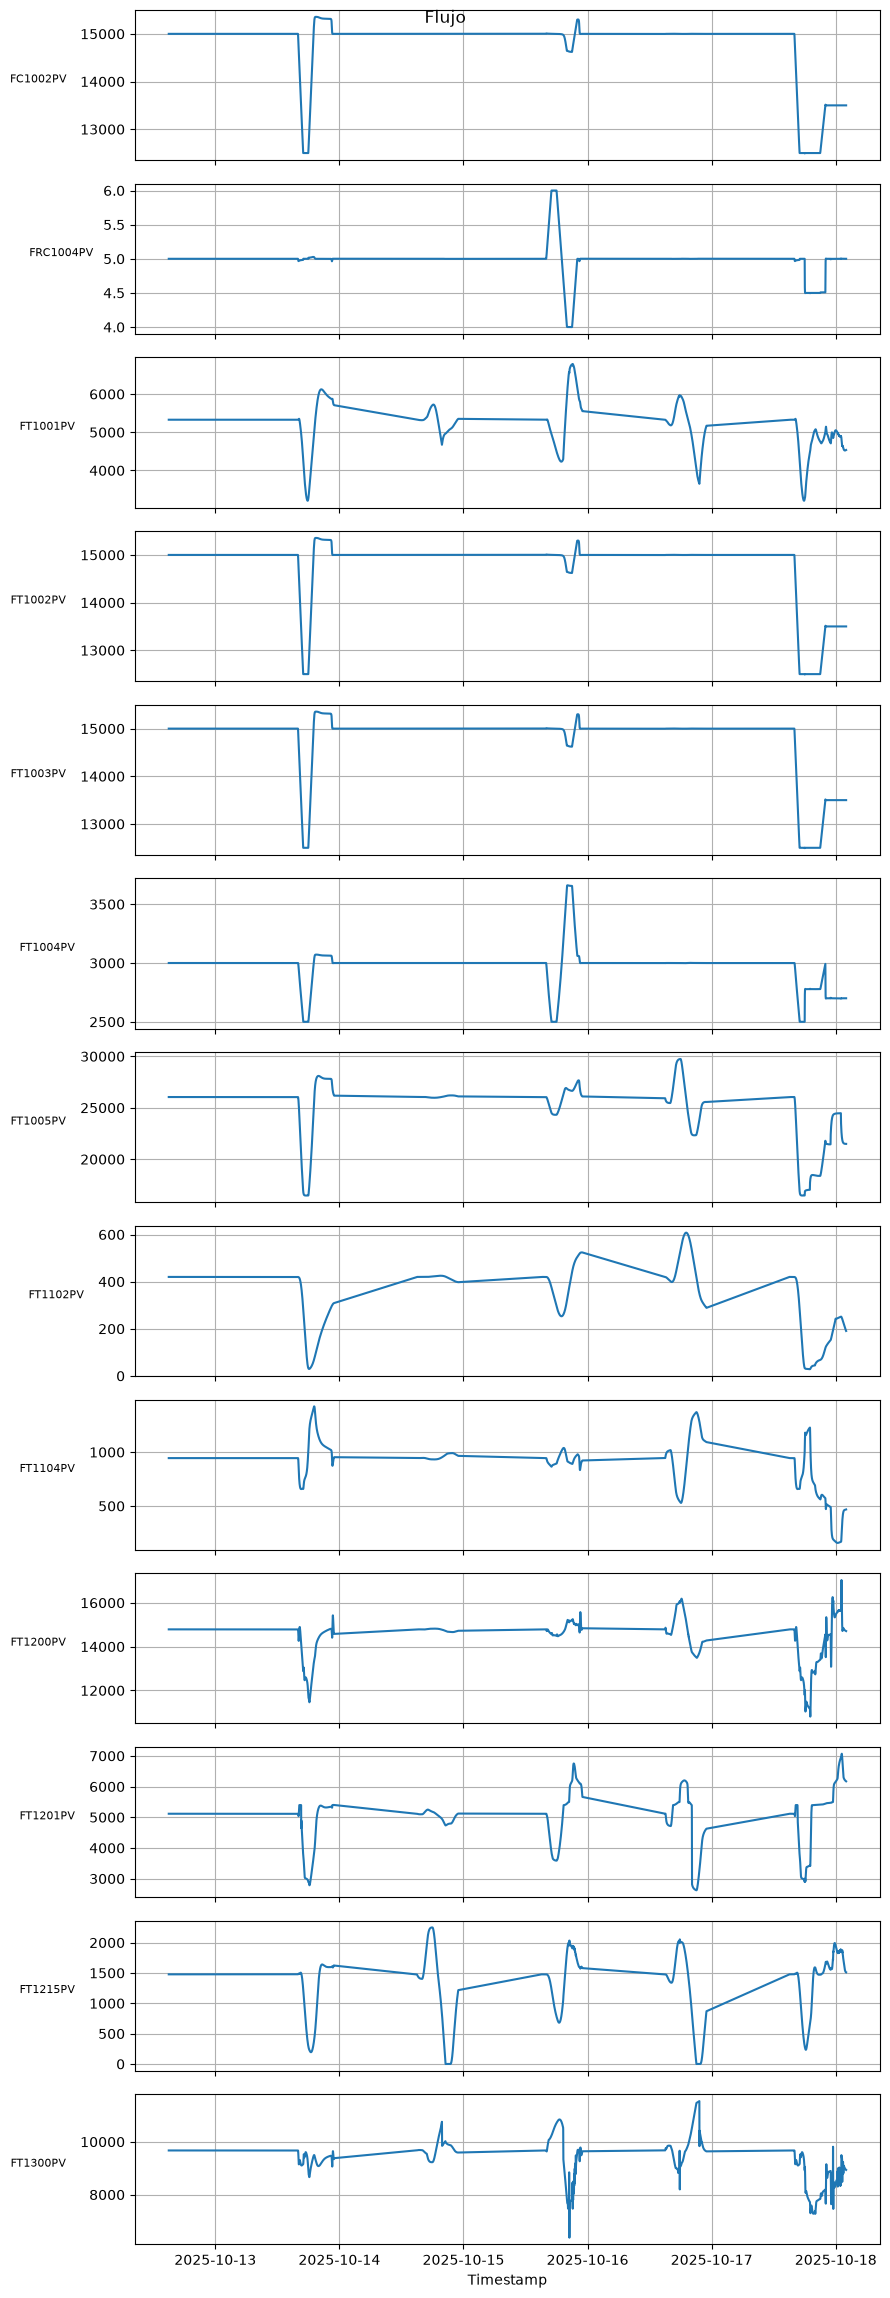

In [7]:
# %% Gráfico de Flujo (excluyendo columnas que terminan en 'SP')
flujo_cols = [c for c in Flujo.columns if not c.endswith('SP')]
stacked_plot(Flujo[flujo_cols], "Flujo")
plt.show()

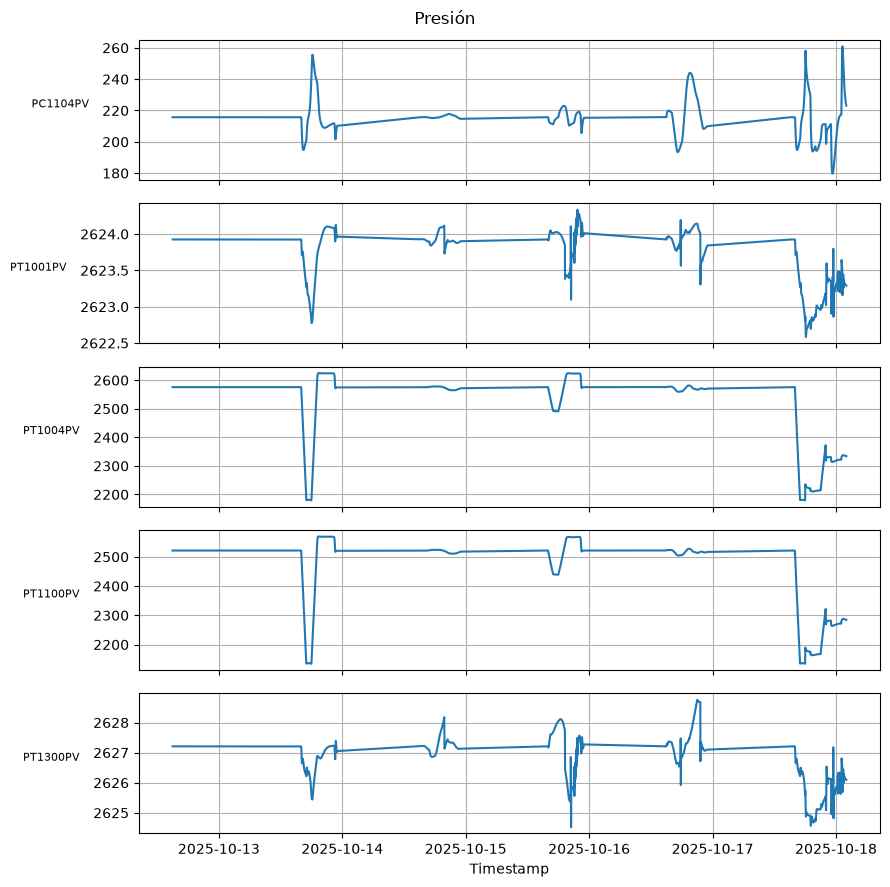

In [8]:
# %% Gráfico de Presión (excluyendo columnas que terminan en 'SP')
presion_cols = [c for c in Presion.columns if not c.endswith('SP')]
stacked_plot(Presion[presion_cols], "Presión")
plt.show()

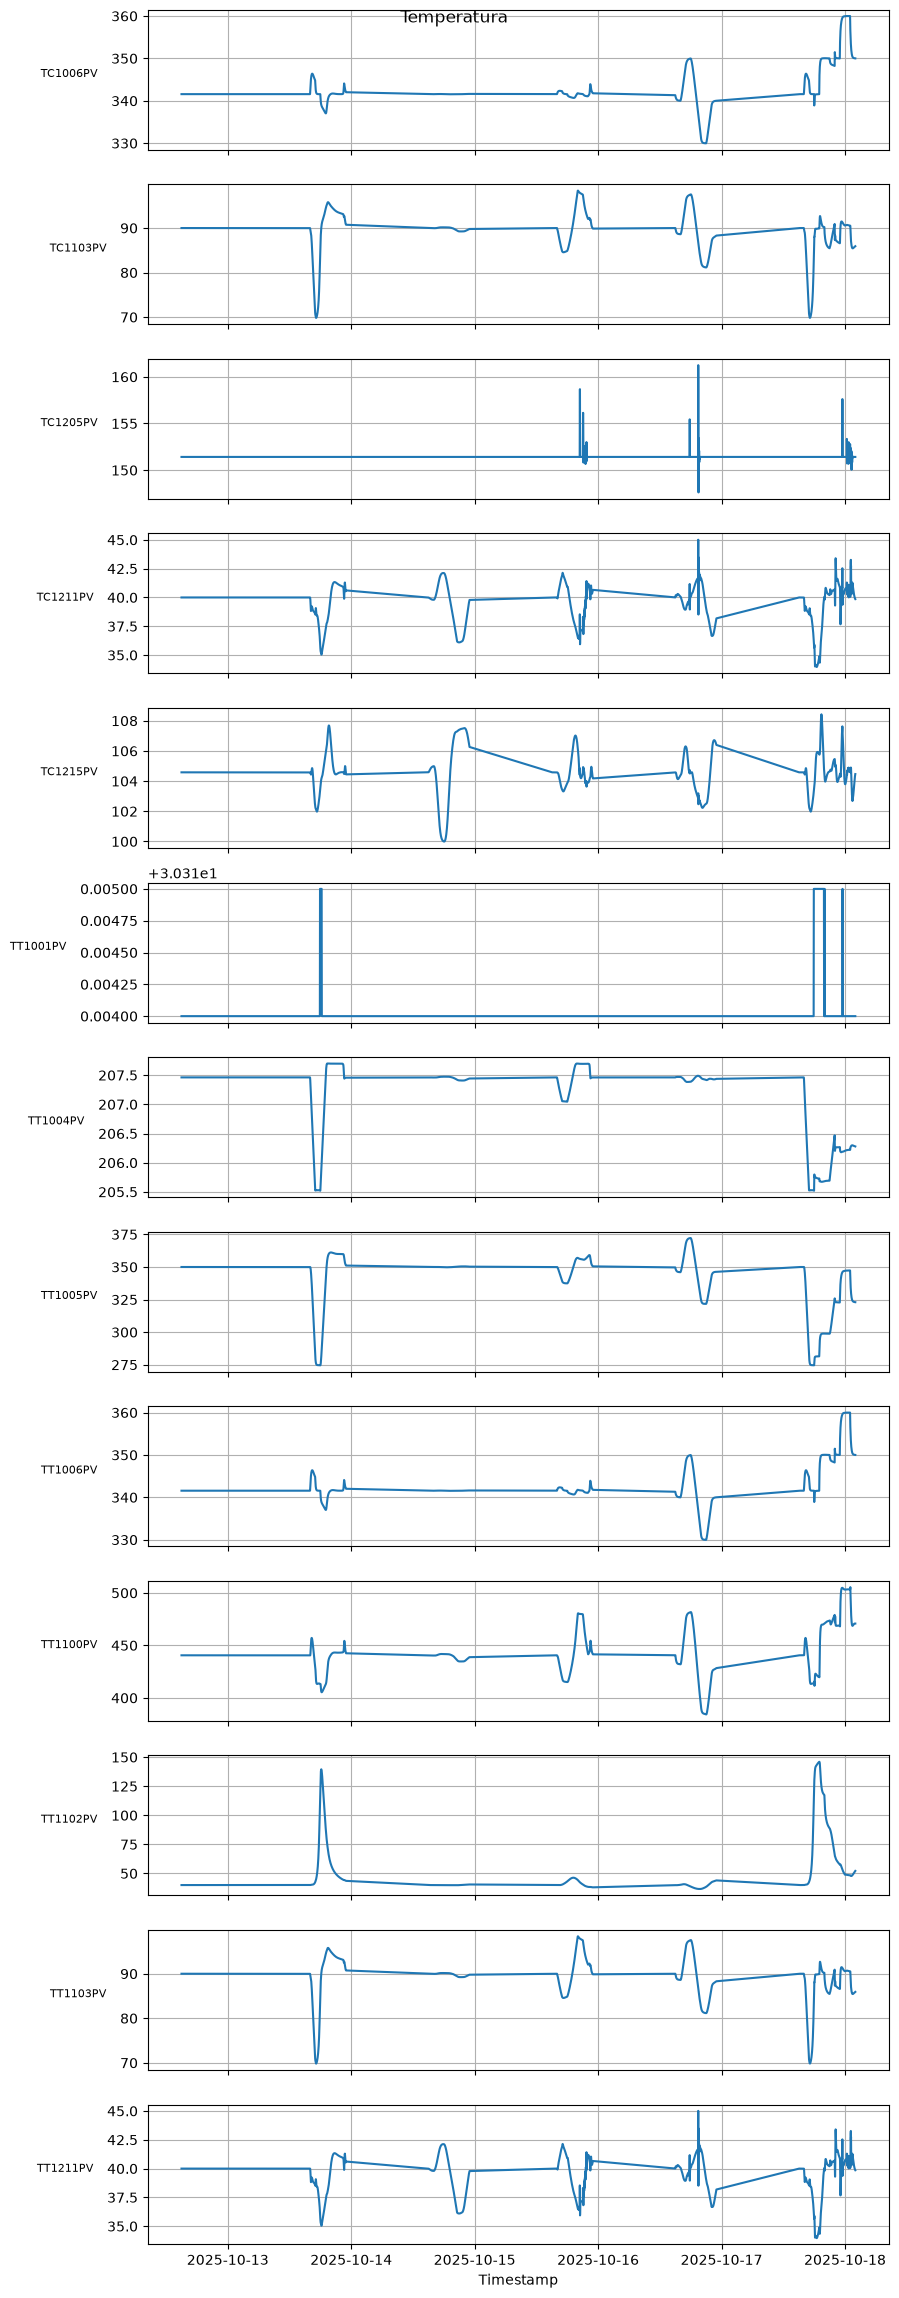

In [9]:
# %% Gráfico de Temperatura (excluyendo columnas que terminan en 'SP')
temp_cols = [c for c in Temperatura.columns if not c.endswith('SP')]
stacked_plot(Temperatura[temp_cols], "Temperatura")
plt.show()

In [10]:
# Cálculo de conversión (X)
# Variables para M_salida: FT1002, FT1004, TT1006
# Variables para M_teórico: TT1100, AT1100, PT1100
# Propiedades de Propeno (A), Benceno (B) y Cumeno (C)
 
# %% Cálculo de conversión
Mi = [42.081, 78.11, 120.19]   # A, B, C. kg/kmol
Nui = [-1, -1, 1]              # A, B, C
 
nA0 = Flujo['FT1004PV'] / Mi[0]   # kmol/h
nB0 = Flujo['FT1002PV'] / Mi[1]   # kmol/h
 
Mmix_teo = (Densidad['AT1100PV'] * 0.08314 * (Temperatura['TT1100PV'] + 273.15)) / (Presion['PT1100PV'] / 100)  # kg/kmol
 
Ext = (Mmix_teo * (nA0 + nB0) - nA0 * Mi[0] - nB0 * Mi[1]) / (Mmix_teo + Mi[2] - Mi[0] - Mi[1])
XA = Nui[0] * Ext / (-nA0)
 
# %% Tabla de resultados de entrada/salida del reactor
RxInOutResults = TimedDataSet[['FT1002PV', 'TT1100PV']].copy()
RxInOutResults['Ext'] = Ext
RxInOutResults['XA'] = XA
RxInOutResults

,FT1002PV,TT1100PV,Ext,XA
Timestamp,,,,
2025-10-12 15:00:00+00:00,15000.000,440.571,58.688538,0.823224
2025-10-12 15:01:00+00:00,15000.000,440.571,58.688538,0.823224
2025-10-12 15:02:00+00:00,15000.000,440.571,58.688538,0.823224
2025-10-12 15:03:00+00:00,15000.000,440.571,58.688538,0.823224
2025-10-12 15:04:00+00:00,15000.000,440.571,58.688538,0.823224
...,...,...,...,...
2025-10-18 01:56:00+00:00,13500.049,470.817,57.884128,0.902125
2025-10-18 01:57:00+00:00,13500.048,470.814,57.896670,0.902321
2025-10-18 01:58:00+00:00,13500.047,470.808,57.913759,0.902588


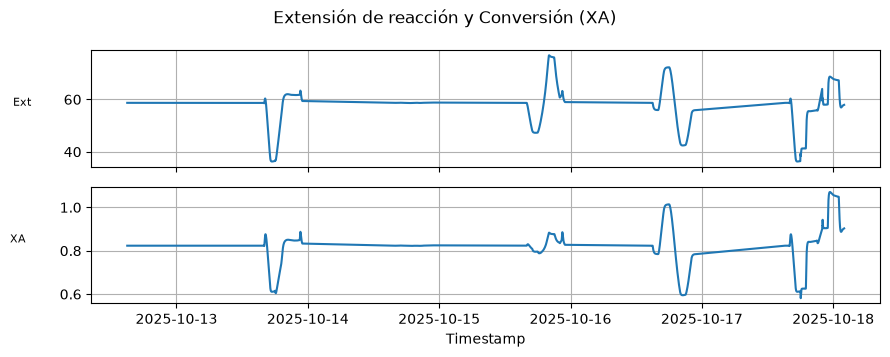

max/min XA: [np.float64(1.0707767048872348), np.float64(0.5812285420448274)]
cantidad de datos: 3066
datos con XA > 1: 183


In [11]:
# %% Gráfico de Ext y XA
stacked_plot(RxInOutResults[['Ext', 'XA']], "Extensión de reacción y Conversión (XA)")
plt.show()
 
# %% Estadísticas finales
maxXa = [XA.max(), XA.min()]
cant = XA.size
cantMax = (XA > 1).sum()
 
print("max/min XA:", maxXa)
print("cantidad de datos:", cant)
print("datos con XA > 1:", cantMax)

Entrenamiento del modelo de ML

In [22]:
ml_df = pd.DataFrame({
    'TT1006PV': TimedDataSet['TT1006PV'],
    'FT1002PV': TimedDataSet['FT1002PV'],
    'FT1004PV': TimedDataSet['FT1004PV'],
    'XA': XA
})

mask_valid = (ml_df['XA'] >= 0) & (ml_df['XA'] <= 1)
print(f"Descartadas {(~mask_valid).sum()} de {len(ml_df)} filas por XA fuera de [0,1]")
ml_df_clean = ml_df[mask_valid].copy()

Descartadas 183 de 3066 filas por XA fuera de [0,1]


In [23]:
# Split cronológico 80/20 (NO aleatorio: es una serie de tiempo)
n = len(ml_df_clean)
split_idx = int(n * 0.8)
train = ml_df_clean.iloc[:split_idx]
test = ml_df_clean.iloc[split_idx:]

X_train = train[['TT1006PV', 'FT1002PV', 'FT1004PV']].values
y_train = train['XA'].values
X_test = test[['TT1006PV', 'FT1002PV', 'FT1004PV']].values
y_test = test['XA'].values

In [19]:
# %% Modelo baseline: regresión lineal múltiple
%pip install -q scikit-learn skl2onnx onnx
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [24]:
model = LinearRegression()
model.fit(X_train, y_train)
pred_test = model.predict(X_test)

print("Coeficientes (TT1006PV, FT1002PV, FT1004PV):", model.coef_)
print("Intercepto:", model.intercept_)
print(f"MAE en test: {mean_absolute_error(y_test, pred_test):.4f}")
print(f"R2 en test: {r2_score(y_test, pred_test):.4f}")

Coeficientes (TT1006PV, FT1002PV, FT1004PV): [2.13613679e-02 6.32814202e-05 9.24742572e-05]
Intercepto: -7.698062720706086
MAE en test: 0.0143
R2 en test: 0.9712


In [26]:
# %% Exportar a ONNX para importar en AVEVA Process Simulation
from skl2onnx import to_onnx

onx = to_onnx(model, X_train[:1].astype(np.float32))
with open("cumenes_conversion_baseline.onnx", "wb") as f:
    f.write(onx.SerializeToString())
print("Modelo exportado a cumenes_conversion_baseline.onnx")

Modelo exportado a cumenes_conversion_baseline.onnx
